# Black-Scholes PDE via RWNN

This notebook demonstrates the RWNN-PDE algorithm applied to a **multi-dimensional
Black-Scholes model** (basket option). We compare the PDE price at $t=0$ against
a Monte Carlo benchmark.

**Reference:** Jacquier & Zuric (2023), *Random neural networks for rough volatility*,
[arXiv:2305.01035](https://arxiv.org/abs/2305.01035)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import random_correlation

from rwnn_pde import BlackScholes, BlackScholesParameters, BSTrainer
from rwnn_pde.payoffs import basket_payoff

plt.style.use('seaborn-v0_8-paper')
rng = np.random.default_rng(42)

## 1. Parameters

We price a basket call on $d = 5$ correlated assets.

In [4]:
d = 5  # number of assets

# Build a structured correlation matrix
sigma = np.linspace(0.05, 0.25, d)
eigs  = d * np.logspace(1, -1, d) / np.logspace(1, -1, d).sum()
Corr  = random_correlation.rvs(eigs=eigs, random_state=0)
Cov   = np.diag(sigma) @ Corr @ np.diag(sigma)

params = BlackScholesParameters(
    S0=np.ones(d),
    T=1.0,
    r=0.05,
    K=np.array([1.0]),
    Cov=Cov,
    opt_style='basket',
    opt_type='c',
    n_hidden_nodes=1000,
    connectivity=0.5,
    input_scaling=0.1,
    weight_compact_radius=0.5,
)

print(f'Volatilities:   {sigma}')
print(f'Correlation matrix:\n{Corr.round(3)}')

Volatilities:   [0.05 0.1  0.15 0.2  0.25]
Correlation matrix:
[[ 1.     0.836 -0.509 -0.701  0.146]
 [ 0.836  1.    -0.665 -0.85   0.407]
 [-0.509 -0.665  1.     0.547 -0.823]
 [-0.701 -0.85   0.547  1.    -0.509]
 [ 0.146  0.407 -0.823 -0.509  1.   ]]


## 2. Simulate Paths

In [5]:
model = BlackScholes(params, N_samples=50_000, n_timesteps=21)
print(f'Path array shape: {model.S.shape}  (N_samples × n_timesteps × d_assets)')

func:'simulate_paths' took: 0.4021 sec
Path array shape: (50000, 21, 5)  (N_samples × n_timesteps × d_assets)


## 3. Solve the PDE via Backward Induction

In [6]:
trainer = BSTrainer(model)
Y = trainer.fit(alpha=params.weight_compact_radius, seed=10)
print(f'Solution array shape: {Y.shape}  (N_samples × n_timesteps × n_strikes)')

func:'fit' took: 114.2607 sec
Solution array shape: (50000, 21, 1)  (N_samples × n_timesteps × n_strikes)


## 4. Results

In [7]:
mc_price  = basket_payoff(S=model.S[:, -1, :], K=params.K).mean(0)
pde_price = Y[:, 0, :].mean(0)

print(f'MC price  (terminal payoff mean):  {mc_price}')
print(f'PDE price (t=0, path mean):        {pde_price}')
print(f'MSE: {((mc_price - pde_price) ** 2).mean():.6e}')

MC price  (terminal payoff mean):  [0.05130627]
PDE price (t=0, path mean):        [0.04899855]
MSE: 5.325584e-06


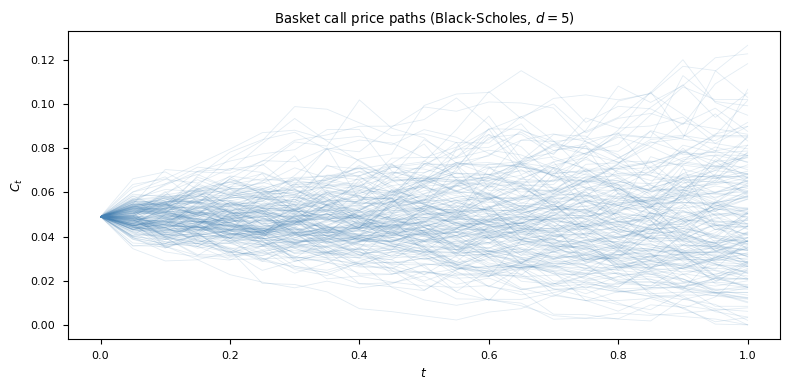

In [8]:
idx = np.random.choice(Y.shape[0], 200, replace=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(model.time_grid, Y[idx, :, 0].T, alpha=0.15, lw=0.6, color='steelblue')
ax.set_xlabel('$t$')
ax.set_ylabel('$C_t$')
ax.set_title('Basket call price paths (Black-Scholes, $d=5$)')
plt.tight_layout()
plt.show()